# Experiment 1: NGRC Weight Analysis on the Lorenz System

### Objectives

- Train an NGRC model on Lorenz system data using $k=1$.
- Examine the learned linear and nonlinear feature weights.
- Identify the dominant terms contributing to $\Delta x$, $\Delta y$, and $\Delta z$.
- Compare the learned interactions with the Euler-discretized Lorenz equations.
- Assess whether NGRC recovers the underlying dynamical structure of the system.

In [1]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Simulation and NVAR Parameters

In [2]:
# Simulation parameters

dt = 0.01

warmup = 5.0
traintime = 10.0
testtime = 120.0
plottime = 20.0
lyaptime = 1.104

maxtime = warmup + traintime + testtime

warmup_pts = round(warmup / dt)
traintime_pts = round(traintime / dt)
warmtrain_pts = warmup_pts + traintime_pts
testtime_pts = round(testtime / dt)
maxtime_pts = round(maxtime / dt)
plottime_pts = round(plottime / dt)
lyaptime_pts = round(lyaptime / dt)

In [3]:
# NG-RC parameters

d = 3
k = 1

dlin = d * k
dnonlin = dlin * (dlin + 1) // 2
dtot = 1 + dlin + dnonlin

ridge_param = 10, #2.5e-6

t_eval = np.linspace(0, maxtime, maxtime_pts + 1)

print(f"{k=}")
print(f"{dlin=}")
print(f"{dnonlin=}")
print(f"{dtot=}")

k=1
dlin=3
dnonlin=6
dtot=10


## Lorenz-63 System

The Lorenz-63 system is a three-dimensional nonlinear dynamical system that exhibits chaotic behavior and serves as a benchmark for testing data-driven forecasting methods.

$$
\begin{aligned}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x(\rho - z) - y, \\
\dot{z} &= xy - \beta z.
\end{aligned}
$$

### Parameters

$$
(\sigma, \rho, \beta)
=
\left(10, 28, \frac{8}{3}\right)
$$

In [4]:
# Lorenz-63 parameters

sigma = 10
beta = 8 / 3
rho = 28


def lorenz(t, state):

    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

In [5]:
# Generate Lorenz trajectory

lorenz_soln = solve_ivp(
    lorenz,
    (0, maxtime),
    [17.67715816276679,
     12.931379185960404,
     43.91404334248268],
    t_eval=t_eval,
    method="RK23"
)

total_var = np.var(lorenz_soln.y[:d, :])

print("State array shape:", lorenz_soln.y.shape)
print("Total variance:", total_var)

State array shape: (3, 13501)
Total variance: 215.98956855733903


## NVAR Feature Construction

Construct the linear and quadratic feature library used by NGRC and assemble the training feature matrix.

In [6]:
# Construct linear feature matrix

x = np.zeros((dlin, maxtime_pts))

for delay in range(k):
    for j in range(delay, maxtime_pts):
        x[d*delay:d*(delay+1), j] = lorenz_soln.y[:, j - delay]

print("Linear feature matrix shape:", x.shape)

Linear feature matrix shape: (3, 13500)


In [7]:
# Construct training feature matrix

out_train = np.ones((dtot, traintime_pts))

out_train[1:dlin+1, :] = x[:, warmup_pts-1:warmtrain_pts-1]

print("Training feature matrix shape:", out_train.shape)

Training feature matrix shape: (10, 1000)


In [8]:
# Add quadratic features

cnt = 0

for i in range(dlin):
    for j in range(i, dlin):

        out_train[dlin + 1 + cnt, :] = (
            x[i, warmup_pts-1:warmtrain_pts-1]
            * x[j, warmup_pts-1:warmtrain_pts-1]
        )

        cnt += 1

print("Number of quadratic features:", cnt)
print("Final feature matrix shape:", out_train.shape)

Number of quadratic features: 6
Final feature matrix shape: (10, 1000)


## NGRC Training

Construct the training target and learn the NGRC readout weights using ridge regression.

In [9]:
# Training target: one-step state increment

Y = (
    x[0:d, warmup_pts:warmtrain_pts]
    - x[0:d, warmup_pts-1:warmtrain_pts-1]
)

print("Target matrix shape:", Y.shape)

Target matrix shape: (3, 1000)


In [10]:
# Compute output weights using ridge regression

W_out = (
    Y @ out_train.T @
    np.linalg.pinv(
        out_train @ out_train.T +
        ridge_param * np.identity(dtot)
    )
)

print("Output weight matrix shape:", W_out.shape)

Output weight matrix shape: (3, 10)


In [11]:
# One-step training prediction

x_predict = (
    x[0:d, warmup_pts-1:warmtrain_pts-1]
    + W_out @ out_train
)

print("Training prediction shape:", x_predict.shape)

Training prediction shape: (3, 1000)


In [12]:
# Training NRMSE

error = (
    x[0:d, warmup_pts:warmtrain_pts]
    - x_predict
)

train_nrmse = np.sqrt(
    np.mean(error**2) / total_var
)

print("Training NRMSE:", train_nrmse)

Training NRMSE: 0.0009019652375075504


## Autonomous Prediction

Generate forecasts using the learned NGRC model without access to future observations and evaluate prediction accuracy over one Lyapunov time.

In [13]:
# Feature vector for one time step

out_test = np.zeros(dtot)

# Predicted trajectory

x_test = np.zeros((dlin, testtime_pts))

# Initialize with final training state

x_test[:, 0] = x[:, warmtrain_pts - 1]


# Autonomous prediction

for j in range(testtime_pts - 1):

    # Linear features
    out_test[1:dlin+1] = x_test[:, j]

    # Quadratic features
    cnt = 0

    for row in range(dlin):
        for col in range(row, dlin):

            out_test[dlin + 1 + cnt] = (
                x_test[row, j]
                * x_test[col, j]
            )

            cnt += 1

    # Shift delay coordinates
    x_test[d:dlin, j+1] = x_test[0:(dlin-d), j]

    # Predict next state
    x_test[0:d, j+1] = (
        x_test[0:d, j]
        + W_out @ out_test
    )


# Test NRMSE over one Lyapunov time

true_segment = x[
    0:d,
    warmtrain_pts-1:warmtrain_pts+lyaptime_pts-1
]

pred_segment = x_test[
    0:d,
    0:lyaptime_pts
]

test_nrmse = np.sqrt(
    np.mean((true_segment - pred_segment)**2)
    / total_var
)

print("Test NRMSE:", test_nrmse)

Test NRMSE: 0.04559839798389552


## Learned Weight Analysis

Examine the learned NGRC weights and compare the dominant features with the interactions expected from the Lorenz equations.

In [14]:
def build_labels(d, k):

    variables = ["x", "y", "z"]

    linear_labels = []

    for delay in range(k):
        for var in variables:

            if delay == 0:
                linear_labels.append(f"{var}(t)")
            else:
                linear_labels.append(f"{var}(t-{delay})")

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):
            labels.append(
                f"{linear_labels[i]}*{linear_labels[j]}"
            )

    return labels


labels = build_labels(d, k)

In [15]:
for i, name in enumerate(["dx", "dy", "dz"]):

    print(f"\n{name}")
    print("-" * 30)

    idx = np.argsort(np.abs(W_out[i]))[::-1]

    for j in idx[:5]:
        print(f"{labels[j]:20s} {W_out[i, j]: .6f}")


dx
------------------------------
y(t)                  0.092071
x(t)                 -0.076674
1                    -0.000851
x(t)*z(t)            -0.000612
z(t)                  0.000135

dy
------------------------------
x(t)                  0.247400
y(t)                  0.016911
x(t)*z(t)            -0.008810
1                     0.008492
z(t)                 -0.001384

dz
------------------------------
1                    -0.024095
z(t)                 -0.022317
x(t)*y(t)             0.008231
x(t)                 -0.003306
y(t)                  0.001909


## Comparison with the Euler-Discretized Lorenz Equations

Using a forward Euler discretization with $h = dt
$$
x_{n+1} = x_n + h\,\sigma(y_n-x_n),
$$

$$
y_{n+1} = y_n + h\,[x_n(\rho-z_n)-y_n],
$$

$$
z_{n+1} = z_n + h\,(x_ny_n-\beta z_n).
$$

The dominant NGRC features are compared with the terms appearing in the corresponding Euler update equations.

In [16]:
h = dt

print("Euler update equations\n")

print(
    f"x(n+1) = x(n)"
    f" {(-h*sigma):+.4f} x(n)"
    f" {(+h*sigma):+.4f} y(n)"
)

print()

print(
    f"y(n+1) = y(n)"
    f" {(+h*rho):+.4f} x(n)"
    f" {(-h):+.4f} y(n)"
    f" {(-h):+.4f} x(n)z(n)"
)

print()

print(
    f"z(n+1) = z(n)"
    f" {(+h):+.4f} x(n)y(n)"
    f" {(-h*beta):+.4f} z(n)"
)

Euler update equations

x(n+1) = x(n) -0.1000 x(n) +0.1000 y(n)

y(n+1) = y(n) +0.2800 x(n) -0.0100 y(n) -0.0100 x(n)z(n)

z(n+1) = z(n) +0.0100 x(n)y(n) -0.0267 z(n)


In [17]:
x_euler = np.zeros((3, testtime_pts))

x_euler[:, 0] = x[:, warmtrain_pts - 1]

for j in range(testtime_pts - 1):

    x_now = x_euler[0, j]
    y_now = x_euler[1, j]
    z_now = x_euler[2, j]

    dx = sigma * (y_now - x_now)
    dy = x_now * (rho - z_now) - y_now
    dz = x_now * y_now - beta * z_now

    x_euler[0, j+1] = x_now + dt * dx
    x_euler[1, j+1] = y_now + dt * dy
    x_euler[2, j+1] = z_now + dt * dz

In [18]:
true = x[
    0:d,
    warmtrain_pts-1:warmtrain_pts+testtime_pts-1
]

pred_ngrc = x_test[0:d, :]
pred_euler = x_euler

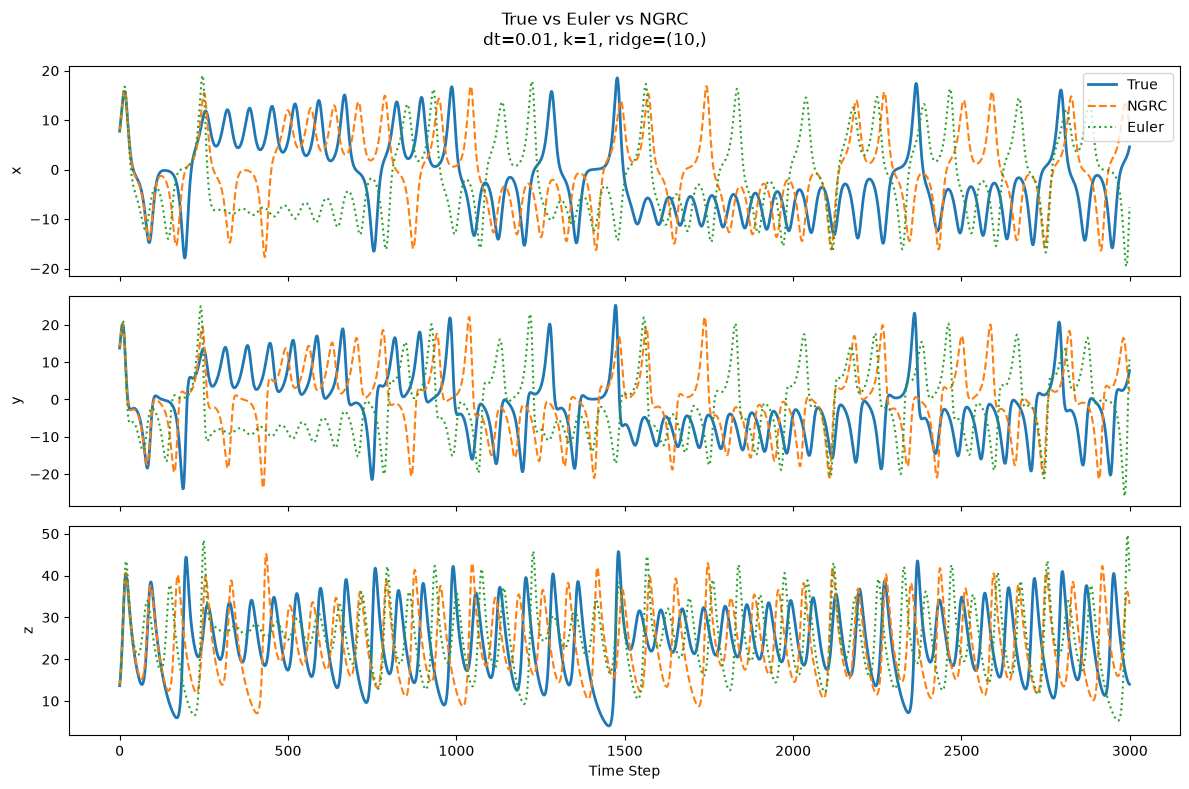

In [19]:
true = x[
    0:d,
    warmtrain_pts-1:warmtrain_pts+testtime_pts-1
]

pred_ngrc = x_test[0:d, :]
pred_euler = x_euler

n = min(3000, pred_ngrc.shape[1])

fig, axs = plt.subplots(
    3, 1,
    figsize=(12,8),
    sharex=True
)

names = ["x", "y", "z"]

for i in range(3):

    axs[i].plot(
        true[i,:n],
        label="True",
        linewidth=2
    )

    axs[i].plot(
        pred_ngrc[i,:n],
        "--",
        label="NGRC"
    )

    axs[i].plot(
        pred_euler[i,:n],
        ":",
        label="Euler"
    )

    

    axs[i].set_ylabel(names[i])

axs[0].legend()

plt.xlabel("Time Step")

plt.suptitle(
    f"True vs Euler vs NGRC\n"
    f"dt={dt}, k={k}, ridge={ridge_param}"
)

plt.tight_layout()
plt.show()